## Installation et import des libraries

In [102]:
%pip install matplotlib --quiet
%pip install numpy --quiet
%pip install tensorflow --quiet
%pip install tabulate --quiet

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
import pathlib
from tabulate import tabulate

## Constantes

In [2]:
DATA_DIR = pathlib.Path("../../datasets/livrable1")
IMAGE_HEIGHT = 180
IMAGE_WIDTH = 180
BATCH_SIZE = 32
NB_EPOCHS = 20

## Traitement

### Suppression des images corrompues

Certaines images du dataset sont corrompues et ne peuvent pas être lues par les fonctions de traitement d'images ce qui génère une erreur lors de l'exécution du code et bloque l'entraînement.
Il est donc nécessaire de supprimer ces images.

In [3]:
# Suppression des images corrompues
num_skipped = 0

for image in DATA_DIR.glob("*/*.*"):
    try:
        img = PIL.Image.open(image)
        img.verify()

        img_bytes = tf.io.read_file(str(image))
        decoded_img = tf.io.decode_image(img_bytes)
    except (IOError, SyntaxError, tf.errors.InvalidArgumentError) as e:
        print("Suppression de l'image corrompue : ", image)
        num_skipped += 1
        image.unlink()

print(f"Nombre d'images corrompues supprimées : {num_skipped}")

Nombre d'images corrompues supprimées : 0


### Conversion des PNG en JPEG

In [43]:
# Conversion des PNG en JPEG
for image in DATA_DIR.glob("*/*.png"):
    try:
        img = PIL.Image.open(image)
        rgb_img = img.convert("RGB")
        new_image_path = image.with_suffix(".jpg")
        rgb_img.save(new_image_path, "JPEG")
        image.unlink()
    except (IOError, SyntaxError) as e:
        print("Erreur lors de la conversion de l'image : ", image)

## Pré-analyse

In [44]:
print("Nombre d'image : ", len(list(DATA_DIR.glob("*/*.jpg"))))

Nombre d'image :  41398


Afficher le nombre d'image pour chaque classe (sous-dossier) dans le dataset afin de vérifier que l'entraînement ne sera pas biaisé par un déséquilibre entre les classes.

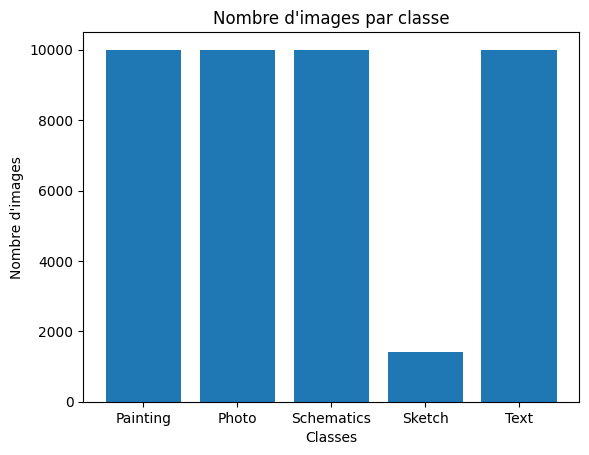

In [4]:
categories = {}

for cat in DATA_DIR.iterdir():
    if cat.is_dir():
        categories[cat.name] = len(list(cat.glob("*.*")))

plt.bar(categories.keys(), categories.values())
plt.xlabel("Classes")
plt.ylabel("Nombre d'images")
plt.title("Nombre d'images par classe")
plt.show()

## Entraînement du modèle

### Création du dataset d'entraînement et de validation

Création de deux datasets. Un d'entraînement qui contient 80% des images étant utilisées pour entraîner le modèle. Le second dataset, de validation, contient les 20% d'images restantes et est utilisé pour évaluer les performances du modèle pendant l'entraînement.

In [5]:
# Le train_set et validation
[train_set, test_set] = tf.keras.preprocessing.image_dataset_from_directory(
  DATA_DIR,
  labels='inferred',
  validation_split=0.2,
  subset ="both",
  seed=42,
  image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
  batch_size=BATCH_SIZE
)

Found 41398 files belonging to 5 classes.
Using 33119 files for training.
Using 8279 files for validation.


### Visualisation des données

In [6]:
class_names = train_set.class_names
print(class_names)

['Painting', 'Photo', 'Schematics', 'Sketch', 'Text']


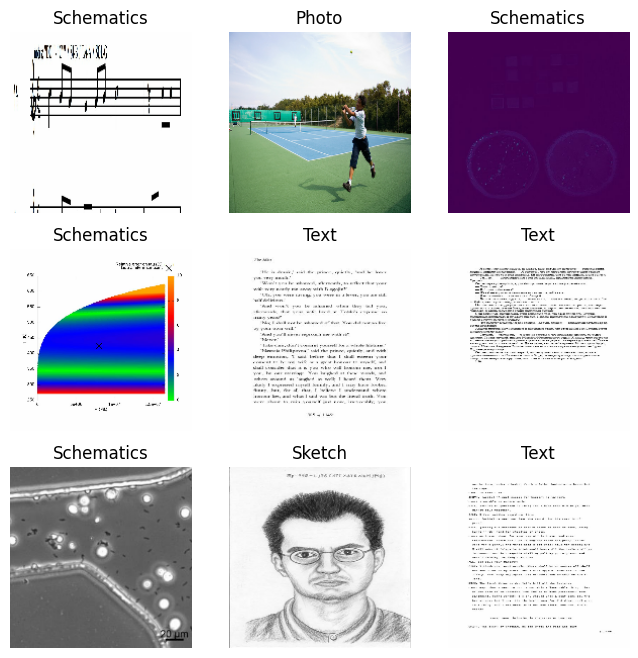

In [10]:
plt.figure(figsize=(8, 8))
for images, labels in train_set.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [129]:
images, labels =  train_set.as_numpy_iterator().next()
print(images.shape)
print(labels.shape)

(32, 180, 180, 3)
(32,)


### Définition des hyperparamètres pour améliorer les performances du modèle

In [11]:
AUTOTUNE = tf.data.experimental.AUTOTUNE

# Garder les images en mémoire afin de ne pas relire les images à chaque epoch (cache).
# Prétraiter les données pendant que le modèle s'entraîne (prefetch).
train_set = train_set.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
test_set = test_set.cache().prefetch(buffer_size=AUTOTUNE)

### Récupération du nombre de classes

In [12]:
# Nombre de classes = nombre de neurones de la couche de sortie du modèle
nombre_classes = len(class_names)

### Création du modèle

In [13]:
# Création du model
model = Sequential([
    layers.Rescaling(1./255, input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3)),
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(nombre_classes, activation='softmax')
])

d:\CoursInge\OptionIntelligenceArtificielle\Projet\.venv-projet\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Compilation du model

In [14]:
# Compilation du model
model.compile(
    optimizer="Adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,989,285 (15.22 MB)

 Trainable params: 3,989,285 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

### Entraînement du model

In [15]:
# Entraînement du model
history = model.fit(
    train_set,
    validation_data=test_set,
    epochs=NB_EPOCHS
)

Epoch 1/20


d:\CoursInge\OptionIntelligenceArtificielle\Projet\.venv-projet\Lib\site-packages\keras\src\backend\tensorflow\nn.py:1216: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


1035/1035 ━━━━━━━━━━━━━━━━━━━━ 110s 91ms/step - accuracy: 0.7867 - loss: 0.5157 - val_accuracy: 0.8232 - val_loss: 0.4268
Epoch 2/20
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 105s 102ms/step - accuracy: 0.8782 - loss: 0.3006 - val_accuracy: 0.8892 - val_loss: 0.2751
Epoch 3/20
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 85s 82ms/step - accuracy: 0.9137 - loss: 0.2235 - val_accuracy: 0.8987 - val_loss: 0.2568
Epoch 4/20
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 84s 81ms/step - accuracy: 0.9400 - loss: 0.1551 - val_accuracy: 0.9068 - val_loss: 0.2700
Epoch 5/20
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 88s 85ms/step - accuracy: 0.9615 - loss: 0.1026 - val_accuracy: 0.8995 - val_loss: 0.3107
Epoch 6/20
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 101s 98ms/step - accuracy: 0.9722 - loss: 0.0768 - val_accuracy: 0.8827 - val_loss: 0.4863
Epoch 7/20
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 99s 96ms/step - accuracy: 0.9798 - loss: 0.0565 - val_accuracy: 0.9026 - val_loss: 0.3665
Epoch 8/20
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 100s 97ms/step - accuracy: 0.9859 - loss:

### Performances du modèle

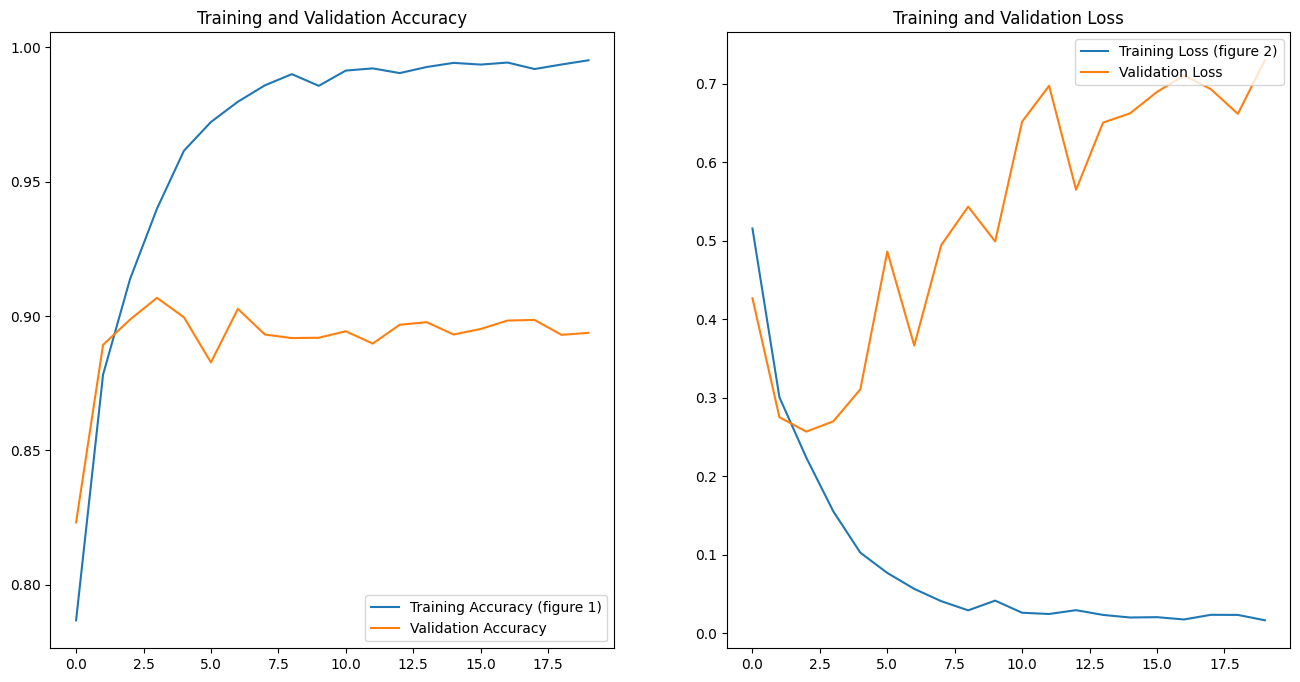

In [16]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(NB_EPOCHS)

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy (figure 1)')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss (figure 2)')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

### Sauvegarde du modèle

In [18]:
model.save('../../models/livrable1/model.keras')

### Interprétation des résultats

La figure 1 nous montre que l'accuracy pour le jeu d'entraînement augmente de manière régulière à chaque epoch,

## Amélioration du modèle

### Dropout

### Data augmentation

### Early stopping

d:\CoursInge\OptionIntelligenceArtificielle\Projet\.venv-projet\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 180, 180, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,989,285 (15.22 MB)

 Trainable params: 3,989,285 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20


d:\CoursInge\OptionIntelligenceArtificielle\Projet\.venv-projet\Lib\site-packages\keras\src\backend\tensorflow\nn.py:1216: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


1035/1035 ━━━━━━━━━━━━━━━━━━━━ 102s 98ms/step - accuracy: 0.7255 - loss: 0.6467 - val_accuracy: 0.7889 - val_loss: 0.5364
Epoch 2/20
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 103s 100ms/step - accuracy: 0.8038 - loss: 0.4832 - val_accuracy: 0.8203 - val_loss: 0.4789
Epoch 3/20
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 102s 98ms/step - accuracy: 0.8267 - loss: 0.4299 - val_accuracy: 0.8439 - val_loss: 0.3886
Epoch 4/20
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 102s 99ms/step - accuracy: 0.8390 - loss: 0.4074 - val_accuracy: 0.8476 - val_loss: 0.3815
Epoch 5/20
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 102s 99ms/step - accuracy: 0.8476 - loss: 0.3829 - val_accuracy: 0.8426 - val_loss: 0.4079
Epoch 6/20
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 101s 98ms/step - accuracy: 0.8582 - loss: 0.3615 - val_accuracy: 0.8372 - val_loss: 0.4371
Epoch 7/20
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 102s 99ms/step - accuracy: 0.8636 - loss: 0.3554 - val_accuracy: 0.8593 - val_loss: 0.4067
Epoch 8/20
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 102s 99ms/step - accuracy: 0.8731 - l

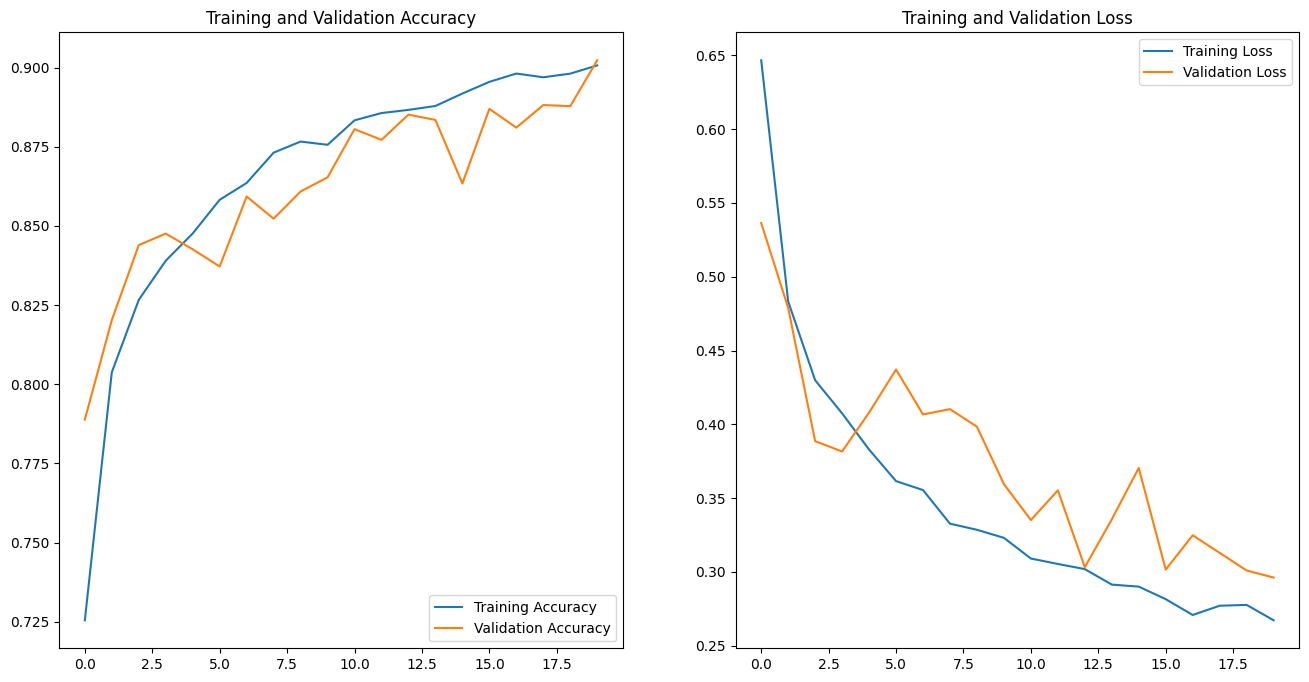

In [19]:
# Création du model
improved_model = Sequential([
    # Augmentation du jeu de données
    layers.RandomFlip("horizontal", input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3)),
    layers.RandomRotation(0.18),
    layers.RandomZoom(0.1),

    # Création des couches
    layers.Rescaling(1./255, input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3)),
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    # Supprimer certains neurones de la couche précédente pour éviter le surapprentissage
    layers.Dropout(0.5),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(nombre_classes, activation='softmax')
])

# Compilation du model
improved_model.compile(
    optimizer="Adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

improved_model.summary()

# Entraînement du model
history_imp_model = improved_model.fit(
    train_set,
    validation_data=test_set,
    epochs=NB_EPOCHS
)

acc = history_imp_model.history['accuracy']
val_acc = history_imp_model.history['val_accuracy']

loss = history_imp_model.history['loss']
val_loss = history_imp_model.history['val_loss']

epochs_range = range(NB_EPOCHS)

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

### Sauvegarde du meilleur modèle

In [25]:
improved_model.save('../../models/livrable1/improved_model.keras')

## Prédiction sur une image de test

In [22]:
random_image = np.random.choice(list(DATA_DIR.glob("*/*.jpg")))

img = keras.preprocessing.image.load_img(
    random_image, target_size=(IMAGE_HEIGHT, IMAGE_WIDTH)
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)

predictions = improved_model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


### Affichage de l'image de test

(np.float64(-0.5), np.float64(179.5), np.float64(179.5), np.float64(-0.5))

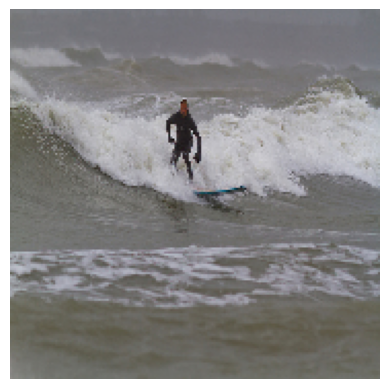

In [23]:
plt.imshow(img)
plt.axis("off")

### Affichage des résultats

In [24]:
score = tf.nn.softmax(predictions[0])

print("Cette image est probablement un {} avec une confiance de {:.2f}%.".format(
    class_names[np.argmax(score)], 100 * np.max(score)
))

res = [
    {"Classe": class_names[i], "Confiance (%)": 100 * score[i]}
    for i in range(len(class_names))
]

print(tabulate([[r["Classe"], r["Confiance (%)"]] for r in res], headers=["Classe", "Confiance (%)"]))

Cette image est probablement un Photo avec une confiance de 35.79%.
Classe        Confiance (%)
----------  ---------------
Painting            17.7442
Photo               35.7864
Schematics          15.6556
Sketch              15.4069
Text                15.4069


### Feature map

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..49.383247].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..201.24037].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..4.3763766].


Painting : 19.37%
Photo : 78.92%
Schematics : 1.72%
Sketch : 0.00%
Text : 0.00%


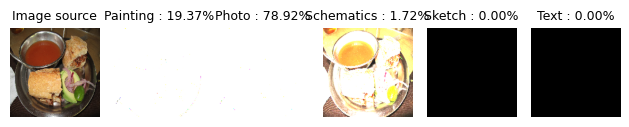

In [138]:
ax = plt.subplot(1, nombre_classes + 1, 1)
plt.title(f"Image source", fontsize=9)
plt.axis("off")
plt.imshow(img_array[0].numpy().astype("uint8"))

for i in range(nombre_classes):
    print(f"{class_names[i]} : {predictions[0][i]*100:.2f}%")
    feature_image = predictions[0][i] * img_array[0].numpy().astype("uint8")
    ax = plt.subplot(1, nombre_classes + 1, i + 2)
    plt.subplots_adjust(wspace=1.5)
    plt.title(f"{class_names[i]} : {predictions[0][i]*100:.2f}%", fontsize=9)
    plt.axis("off")
    plt.imshow(feature_image, cmap="viridis")

plt.tight_layout()
plt.show()